# 9. Model Comparison and Results Summary

This notebook combines the results from all tabular and graph-based models developed in the project. The objective is to compare Logistic Regression, Random Forest, XGBoost, GCN, tuned-threshold GCN, GAT, and tuned-threshold GAT using the same test-set evaluation metrics.

The comparison focuses especially on precision, recall, F1-score, ROC-AUC, and PR-AUC because the dataset is highly imbalanced and illicit transactions represent the minority class.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 9.1 Set Project Paths

The results generated from previous notebooks are loaded from the project results directory.

In [2]:
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Results directory:", RESULTS_DIR.relative_to(PROJECT_DIR))
print("Figures directory:", FIGURES_DIR.relative_to(PROJECT_DIR))

Results directory: results
Figures directory: figures


## 9.2 Create Final Model Comparison Table

The final model comparison table is created using the validated test results from the previous notebooks.

In [3]:
comparison_data = [
    {
        "model": "Logistic Regression",
        "model_type": "Tabular ML",
        "threshold_type": "Default",
        "accuracy": 0.8775,
        "precision": 0.4395,
        "recall": 0.9274,
        "f1": 0.5964,
        "roc_auc": 0.9645,
        "pr_auc": 0.7475
    },
    {
        "model": "Random Forest",
        "model_type": "Tabular ML",
        "threshold_type": "Default",
        "accuracy": 0.9875,
        "precision": 0.9521,
        "recall": 0.9186,
        "f1": 0.9351,
        "roc_auc": 0.9958,
        "pr_auc": 0.9774
    },
    {
        "model": "XGBoost",
        "model_type": "Tabular ML",
        "threshold_type": "Default",
        "accuracy": 0.9918,
        "precision": 0.9749,
        "recall": 0.9406,
        "f1": 0.9574,
        "roc_auc": 0.9974,
        "pr_auc": 0.9860
    },
    {
        "model": "GCN",
        "model_type": "Graph Neural Network",
        "threshold_type": "Default",
        "accuracy": 0.9283,
        "precision": 0.5863,
        "recall": 0.9010,
        "f1": 0.7103,
        "roc_auc": 0.9748,
        "pr_auc": 0.8530
    },
    {
        "model": "GCN Tuned Threshold",
        "model_type": "Graph Neural Network",
        "threshold_type": "Tuned",
        "accuracy": 0.9634,
        "precision": 0.8220,
        "recall": 0.7976,
        "f1": 0.8096,
        "roc_auc": 0.9748,
        "pr_auc": 0.8530
    },
    {
        "model": "GAT",
        "model_type": "Graph Neural Network",
        "threshold_type": "Default",
        "accuracy": 0.7685,
        "precision": 0.2899,
        "recall": 0.9461,
        "f1": 0.4438,
        "roc_auc": 0.9566,
        "pr_auc": 0.7962
    },
    {
        "model": "GAT Tuned Threshold",
        "model_type": "Graph Neural Network",
        "threshold_type": "Tuned",
        "accuracy": 0.9480,
        "precision": 0.7297,
        "recall": 0.7426,
        "f1": 0.7361,
        "roc_auc": 0.9566,
        "pr_auc": 0.7962
    }
]

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,model,model_type,threshold_type,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,Tabular ML,Default,0.8775,0.4395,0.9274,0.5964,0.9645,0.7475
1,Random Forest,Tabular ML,Default,0.9875,0.9521,0.9186,0.9351,0.9958,0.9774
2,XGBoost,Tabular ML,Default,0.9918,0.9749,0.9406,0.9574,0.9974,0.9860
3,GCN,Graph Neural Network,Default,0.9283,0.5863,0.9010,0.7103,0.9748,0.8530
4,GCN Tuned Threshold,Graph Neural Network,Tuned,0.9634,0.8220,0.7976,0.8096,0.9748,0.8530
5,GAT,Graph Neural Network,Default,0.7685,0.2899,0.9461,0.4438,0.9566,0.7962
6,GAT Tuned Threshold,Graph Neural Network,Tuned,0.9480,0.7297,0.7426,0.7361,0.9566,0.7962


In [ ]:
comparison_csv_path = RESULTS_DIR / "final_model_comparison_table.csv"

comparison_df.to_csv(
    comparison_csv_path,
    index=False
)

print("Final comparison table saved to:")
print(comparison_csv_path.relative_to(PROJECT_DIR))

## 9.3 Rank Models by Key Metrics

The models are ranked by F1-score and PR-AUC. F1-score summarizes the balance between precision and recall, while PR-AUC is especially useful for imbalanced classification problems such as fraud detection.

In [5]:
rank_by_f1 = comparison_df.sort_values(by="f1", ascending=False)
rank_by_pr_auc = comparison_df.sort_values(by="pr_auc", ascending=False)
rank_by_recall = comparison_df.sort_values(by="recall", ascending=False)

print("Models ranked by F1-score:")
display(rank_by_f1[["model", "precision", "recall", "f1", "pr_auc"]])

print("Models ranked by PR-AUC:")
display(rank_by_pr_auc[["model", "precision", "recall", "f1", "pr_auc"]])

print("Models ranked by recall:")
display(rank_by_recall[["model", "precision", "recall", "f1", "pr_auc"]])

Models ranked by F1-score:


,model,precision,recall,f1,pr_auc
2,XGBoost,0.9749,0.9406,0.9574,0.9860
1,Random Forest,0.9521,0.9186,0.9351,0.9774
4,GCN Tuned Threshold,0.8220,0.7976,0.8096,0.8530
6,GAT Tuned Threshold,0.7297,0.7426,0.7361,0.7962
3,GCN,0.5863,0.9010,0.7103,0.8530
0,Logistic Regression,0.4395,0.9274,0.5964,0.7475
5,GAT,0.2899,0.9461,0.4438,0.7962


Models ranked by PR-AUC:


,model,precision,recall,f1,pr_auc
2,XGBoost,0.9749,0.9406,0.9574,0.9860
1,Random Forest,0.9521,0.9186,0.9351,0.9774
3,GCN,0.5863,0.9010,0.7103,0.8530
4,GCN Tuned Threshold,0.8220,0.7976,0.8096,0.8530
5,GAT,0.2899,0.9461,0.4438,0.7962
6,GAT Tuned Threshold,0.7297,0.7426,0.7361,0.7962
0,Logistic Regression,0.4395,0.9274,0.5964,0.7475


Models ranked by recall:


,model,precision,recall,f1,pr_auc
5,GAT,0.2899,0.9461,0.4438,0.7962
2,XGBoost,0.9749,0.9406,0.9574,0.9860
0,Logistic Regression,0.4395,0.9274,0.5964,0.7475
1,Random Forest,0.9521,0.9186,0.9351,0.9774
3,GCN,0.5863,0.9010,0.7103,0.8530
4,GCN Tuned Threshold,0.8220,0.7976,0.8096,0.8530
6,GAT Tuned Threshold,0.7297,0.7426,0.7361,0.7962


## 9.4 Visual Comparison of Model Performance

The following plots compare the models using the main fraud detection metrics.

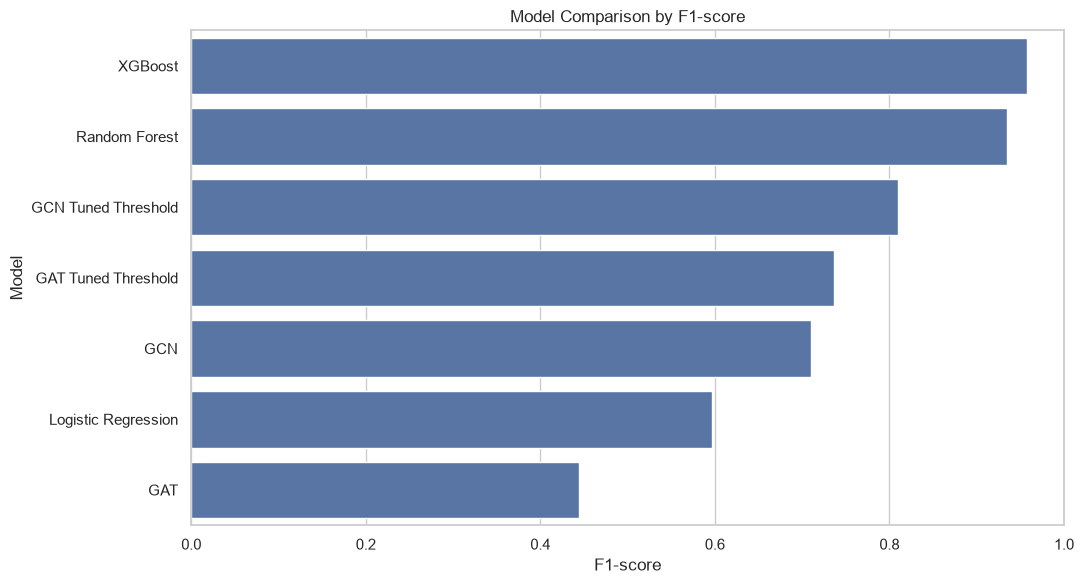

In [6]:
plt.figure(figsize=(11, 6))
sns.barplot(data=comparison_df.sort_values(by="f1", ascending=False), x="f1", y="model")
plt.title("Model Comparison by F1-score")
plt.xlabel("F1-score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_f1_score.png", dpi=300)
plt.show()

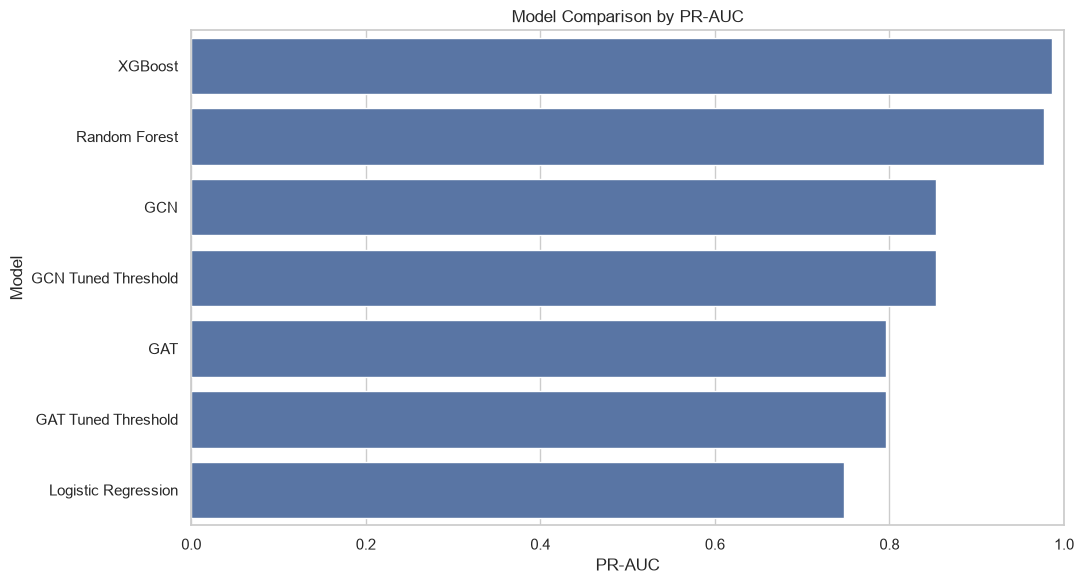

In [7]:
plt.figure(figsize=(11, 6))
sns.barplot(data=comparison_df.sort_values(by="pr_auc", ascending=False), x="pr_auc", y="model")
plt.title("Model Comparison by PR-AUC")
plt.xlabel("PR-AUC")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_pr_auc.png", dpi=300)
plt.show()

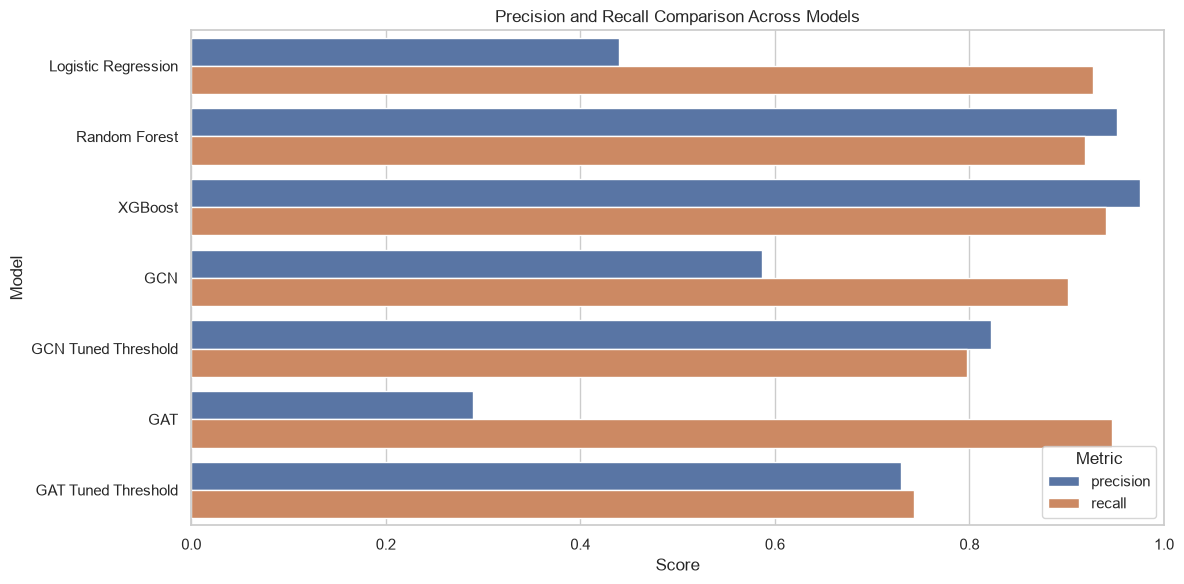

In [8]:
precision_recall_df = comparison_df.melt(
    id_vars=["model", "model_type", "threshold_type"],
    value_vars=["precision", "recall"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=precision_recall_df, x="score", y="model", hue="metric")
plt.title("Precision and Recall Comparison Across Models")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_precision_recall.png", dpi=300)
plt.show()

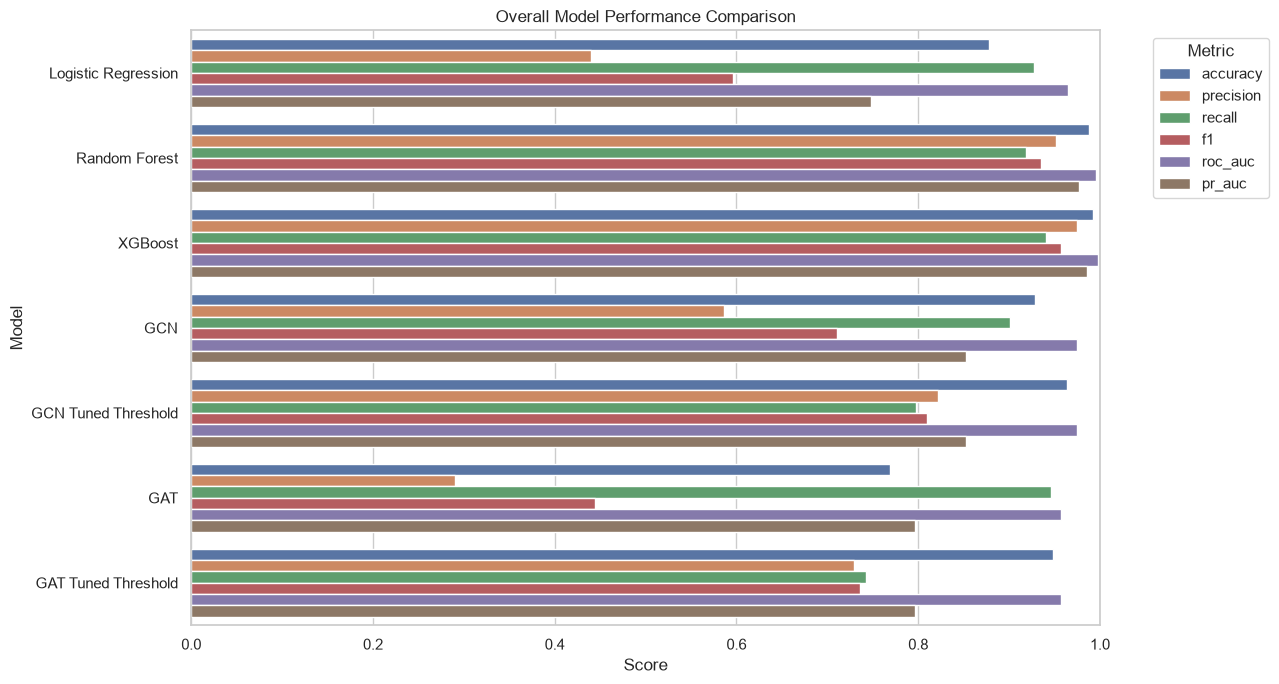

In [9]:
metrics_long_df = comparison_df.melt(
    id_vars=["model", "model_type", "threshold_type"],
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(13, 7))
sns.barplot(data=metrics_long_df, x="score", y="model", hue="metric")
plt.title("Overall Model Performance Comparison")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "overall_model_performance_comparison.png", dpi=300)
plt.show()

## 9.5 Tabular Models vs Graph Neural Networks

This section compares the best tabular model with the best graph-based model.

In [10]:
tabular_df = comparison_df[comparison_df["model_type"] == "Tabular ML"]
graph_df = comparison_df[comparison_df["model_type"] == "Graph Neural Network"]

best_tabular = tabular_df.sort_values(by="f1", ascending=False).iloc[0]
best_graph = graph_df.sort_values(by="f1", ascending=False).iloc[0]

print("Best tabular model by F1-score:")
display(best_tabular.to_frame().T)

print("Best graph model by F1-score:")
display(best_graph.to_frame().T)

summary_best_models = pd.DataFrame([best_tabular, best_graph])
summary_best_models.to_csv(
    RESULTS_DIR / "best_tabular_vs_best_graph_model.csv",
    index=False
)

Best tabular model by F1-score:


,model,model_type,threshold_type,accuracy,precision,recall,f1,roc_auc,pr_auc
2,XGBoost,Tabular ML,Default,0.9918,0.9749,0.9406,0.9574,0.9974,0.986


Best graph model by F1-score:


,model,model_type,threshold_type,accuracy,precision,recall,f1,roc_auc,pr_auc
4,GCN Tuned Threshold,Graph Neural Network,Tuned,0.9634,0.822,0.7976,0.8096,0.9748,0.853


## 9.6 Final Results Interpretation

The final comparison shows that XGBoost achieved the strongest overall performance among all models. It produced the highest F1-score and PR-AUC, indicating that the tabular feature space contains strong predictive signal for illicit transaction detection.

The graph-based models also provided useful results. The default GCN achieved high recall, meaning it detected a large proportion of illicit transactions, but it produced more false positives than the strongest tabular models. Threshold tuning improved the GCN by increasing precision and F1-score. The default GAT achieved very high recall but had low precision due to a large number of false positives. After threshold tuning, GAT became more balanced, although it still did not outperform XGBoost or the tuned GCN.

Overall, the results suggest that graph-based learning is valuable for modeling transaction-network structure, but in this experimental setup, it did not automatically outperform strong tabular machine learning baselines. This finding is important because it supports the need for careful benchmarking rather than assuming that graph neural networks will always be superior on graph-structured fraud detection data.

In [11]:
final_interpretation = """
The final comparison shows that XGBoost achieved the strongest overall performance among all models.
It produced the highest F1-score and PR-AUC, indicating that the tabular feature space contains strong predictive signal for illicit transaction detection.

The graph-based models also provided useful results. The default GCN achieved high recall, meaning it detected a large proportion of illicit transactions, but it produced more false positives than the strongest tabular models.
Threshold tuning improved the GCN by increasing precision and F1-score.
The default GAT achieved very high recall but had low precision due to a large number of false positives.
After threshold tuning, GAT became more balanced, although it still did not outperform XGBoost or the tuned GCN.

Overall, the results suggest that graph-based learning is valuable for modeling transaction-network structure, but in this experimental setup, it did not automatically outperform strong tabular machine learning baselines.
This finding is important because it supports the need for careful benchmarking rather than assuming that graph neural networks will always be superior on graph-structured fraud detection data.
"""

final_interpretation_path = RESULTS_DIR / "final_results_interpretation.txt"

with open(final_interpretation_path, "w") as f:
    f.write(final_interpretation)

print("Final interpretation saved to:")
print(final_interpretation_path.relative_to(PROJECT_DIR))

Final interpretation saved to:
results\final_results_interpretation.txt


## 9.7 Tuned-Threshold Confusion Matrix Visualizations

The tuned-threshold versions of GCN and GAT are visualized separately because threshold tuning changed the final class predictions and improved the balance between precision and recall. These confusion matrices help show how false positives and false negatives changed after threshold adjustment.

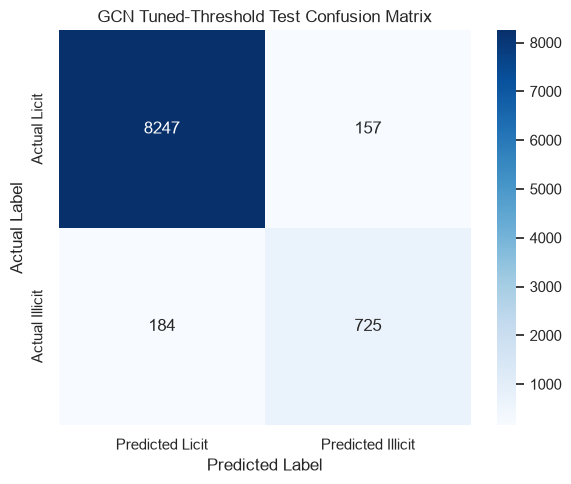

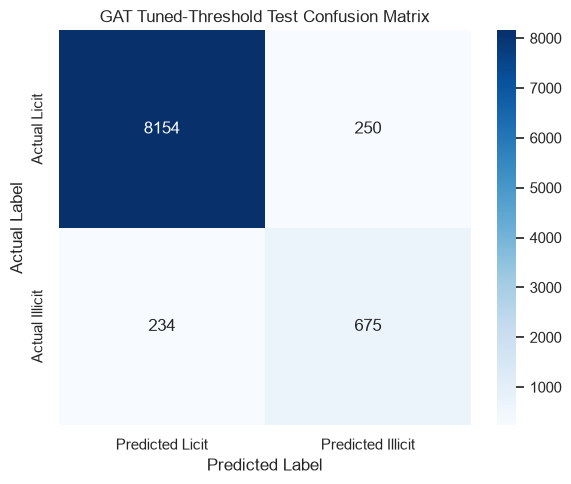

Tuned-threshold confusion matrix figures saved.


In [12]:
# Tuned-threshold confusion matrices based on previous results

gcn_tuned_cm = np.array([
    [8247, 157],
    [184, 725]
])

gat_tuned_cm = np.array([
    [8154, 250],
    [234, 675]
])

plt.figure(figsize=(6, 5))
sns.heatmap(
    gcn_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Licit", "Predicted Illicit"],
    yticklabels=["Actual Licit", "Actual Illicit"]
)
plt.title("GCN Tuned-Threshold Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gcn_tuned_threshold_confusion_matrix.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(
    gat_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Licit", "Predicted Illicit"],
    yticklabels=["Actual Licit", "Actual Illicit"]
)
plt.title("GAT Tuned-Threshold Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gat_tuned_threshold_confusion_matrix.png", dpi=300)
plt.show()

print("Tuned-threshold confusion matrix figures saved.")

## 9.8 Summary

This notebook produced the final comparative model analysis for the project. The main result is that XGBoost achieved the strongest overall performance, while GCN and GAT provided useful graph-based comparison points. Threshold tuning improved the graph neural network models, especially by reducing false positives and improving the balance between precision and recall.